In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

/ihome/djishnu/alo90/.local/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/ihome/djishnu/alo90/.local/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
coreTFR = pd.read_csv('../../Data/literature_sets/dalit_coreTFR_genes.csv')
coreTFH = pd.read_csv('../../Data/literature_sets/dalit_coreTFH_genes.csv')
corenet_biomart = pd.read_csv('../../Data/Input_data/biomart_corenet.csv')

In [3]:
corenet_biomart = corenet_biomart.dropna(subset=['Mouse gene name'])
mouse_gene_names = corenet_biomart.rename(columns={'Gene name':'Genes'})

corenet_biomart_set = set(corenet_biomart['Mouse gene name'])
coreTFR_set = set(coreTFR['Genes'])
coreTFH_set = set(coreTFH['Genes'])

overlap_coreTFR = corenet_biomart_set & coreTFR_set 
overlap_coreTFH = corenet_biomart_set & coreTFH_set
overlap_both = overlap_coreTFR & overlap_coreTFH

overlap_coreTFH_and_coreTFR = overlap_coreTFR.union(overlap_coreTFH)

In [4]:
###Get the RNA expression values
rna_seq = pd.read_csv('../../Data/bulk_RNA/rna_seq_mean.csv')
GC_rna_seq = rna_seq[['Genes','GC Tfh', 'Early_Extra_GC_Tfh', 'Late_Extra_GC_Tfh']]
GC_rna_seq = GC_rna_seq.merge(mouse_gene_names, on= 'Genes').drop(columns={'Unnamed: 0'}).rename(columns={'Genes':'Human gene', 'Mouse gene name':'Genes'})

In [5]:
deg_analysis = pd.DataFrame()
deg_analysis['Genes'] = list(overlap_coreTFH_and_coreTFR)
deg_analysis = deg_analysis.merge(GC_rna_seq, on= 'Genes')

In [6]:
#Identify if it is a Tfh, Tfr, or both gene
group = []
for gene in deg_analysis['Genes']:
    if gene in overlap_both:
        group.append('Tfh/Tfr')
        print('Tfh/Tfr gene')
    elif gene in overlap_coreTFR:
        group.append('Tfr')
    elif gene in overlap_coreTFH:
        group.append('Tfh')
    else:
        group.append('NA')

Tfh/Tfr gene
Tfh/Tfr gene
Tfh/Tfr gene
Tfh/Tfr gene
Tfh/Tfr gene
Tfh/Tfr gene
Tfh/Tfr gene
Tfh/Tfr gene
Tfh/Tfr gene


In [7]:
deg_analysis['Group'] = group
deg_analysis["log2FC_Early_vs_GC"] = np.log2((deg_analysis["GC Tfh"]) / (deg_analysis["Early_Extra_GC_Tfh"]))
deg_analysis["log2FC_Late_vs_GC"] = np.log2((deg_analysis["GC Tfh"]) / (deg_analysis["Late_Extra_GC_Tfh"]))

# Clip both log2FC columns
deg_analysis[["log2FC_Early_vs_GC", "log2FC_Late_vs_GC"]] = (
    deg_analysis[["log2FC_Early_vs_GC", "log2FC_Late_vs_GC"]]
    .clip(lower=-4, upper=4)
)

In [24]:
deg_analysis.to_csv('Tfh_tfr_deg_analysis.csv')

In [8]:
group_order = ['Tfh', 'Tfh/Tfr', 'Tfr']

deg_ordered = deg_analysis.sort_values(
    by=["Group", "log2FC_Early_vs_GC"], ascending = True,
    key=lambda x: x.map({g: i for i, g in enumerate(group_order)}) 
    if x.name == "Group" else x
)

heatmap_data = (
    deg_ordered
    .set_index("Genes")[["log2FC_Early_vs_GC"]]
)

row_colors = deg_ordered.set_index("Genes")["Group"].map({
    "Tfh": "#1f77b4",
    "Tfh/Tfr": "#2ca02c",
    "Tfr": "#ff7f0e"
})

0.265007974155533


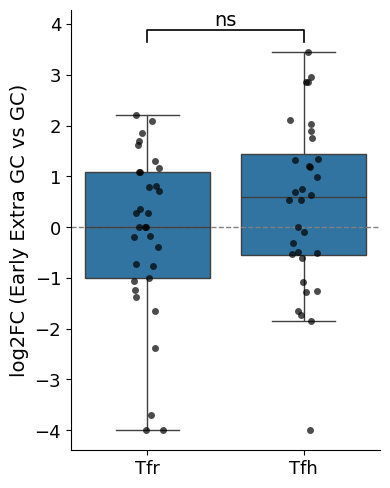

In [9]:
# -----------------------------
# 0. Remove Tfh/Tfr group
# -----------------------------
df = deg_analysis[deg_analysis["Group"].isin(["Tfh", "Tfr"])].copy()

# -----------------------------
# 1. Mann–Whitney U test
# -----------------------------
x1 = df.loc[df["Group"] == "Tfh", "log2FC_Early_vs_GC"]
x2 = df.loc[df["Group"] == "Tfr", "log2FC_Early_vs_GC"]

stat, p_val = mannwhitneyu(x1, x2, alternative="two-sided")
print(p_val)

# Helper: p-value to stars
def p_to_star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

# -----------------------------
# 2. Plot
# -----------------------------
plt.figure(figsize=(4, 5))  # narrower since only 2 groups
ax = sns.boxplot(
    data=df,
    x="Group",
    y="log2FC_Early_vs_GC",
    showfliers=False
)

sns.stripplot(
    data=df,
    x="Group",
    y="log2FC_Early_vs_GC",
    color="black",
    size=5,
    jitter=True,
    alpha=0.7
)

# Zero line
ax.axhline(0, linestyle="--", color="gray", linewidth=1)

# Clean spines
sns.despine(ax=ax, top=True, right=True)

# Labels & fonts
ax.set_ylabel("log2FC (Early Extra GC vs GC)", fontsize=14)
ax.set_xlabel("")
ax.tick_params(axis="x", labelsize=13)
ax.tick_params(axis="y", labelsize=13)

# -----------------------------
# 3. Add significance
# -----------------------------
y_max = df["log2FC_Early_vs_GC"].max()
h = 0.25

ax.plot([0, 0, 1, 1], [y_max + 0.2, y_max + 0.2 + h, y_max + 0.2 + h, y_max + 0.2],
        lw=1.2, c="black")
ax.text(
    0.5,
    y_max + 0.2 + h,
    p_to_star(p_val),
    ha="center",
    va="bottom",
    fontsize=14
)

plt.tight_layout()

#plt.savefig("log2FC_Late_vs_GC_Tfh_vs_Tfr.png", dpi=300, bbox_inches="tight")
#plt.savefig("log2FC_Late_vs_GC_Tfh_vs_Tfr.pdf", bbox_inches="tight")

plt.show()